In [1]:
import pandas as pd
import numpy as np
try:
    from pgmpy.models import DiscreteBayesianNetwork as DBN
except ImportError:
    from pgmpy.models import BayesianNetwork as DBN

from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

# 1. 数据读取、列名清洗与数据转换
file_path = r'e:\26春 机器学习\期中\campusBicyclesharingdataset.xlsx'
df = pd.read_excel(file_path)

# 合并列名映射和数据转换
col_map = {df.columns[i]: name for i, name in enumerate(['A', 'B', 'E1', 'E2', 'E3', 'E4'])}
mapping = {'高': 1, '低': 0}
df = df.rename(columns=col_map)
df[['A','B','E1','E2','E3','E4']] = df[['A','B','E1','E2','E3','E4']].apply(lambda col: pd.to_numeric(col.astype(str).str.strip().replace(mapping), errors='coerce').fillna(0).astype(int))

# 3. 结构学习：定义有向无环图 (DAG)
model = DBN([
    ('E4', 'B'),   
    ('E4', 'E1'), 
    ('E1', 'E2'), 
    ('E1', 'E3'), 
    ('E2', 'A'),   
    ('E3', 'A')    
 ])

# 4. [Q4.2] 参数学习：估计条件概率表 (CPT)
model.fit(df, estimator=DiscreteMLE())

print("--- 4.2 各节点的条件概率表 (CPT) ---")
for node in model.nodes():
    print(f"节点 {node} 的 CPT：")
    print(model.get_cpds(node))
    print('-'*40)
# 5. [Q4.3] 预测推理：已知 E4 为高 (1)，预测 A 为高 (1) 的概率
infer = VariableElimination(model)
# 查询在证据 E4=1 的情况下，A 的分布
result = infer.query(variables=['A'], evidence={'E4': 1})

print("\n--- 4.3 预测推理结果 (P(A | E4=高)) ---")
print(result)

prob_a_high = result.values[1]
print(f"\n结论：当服务稳定性 E4 为高时，车辆分布合理性 A 为高的概率为 {prob_a_high:.2%}")

e:\miniconda\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


--- 4.2 各节点的条件概率表 (CPT) ---
节点 E4 的 CPT：
+-------+-----+
| E4(0) | 0.3 |
+-------+-----+
| E4(1) | 0.7 |
+-------+-----+
----------------------------------------
节点 B 的 CPT：
+------+--------------------+--------------------+
| E4   | E4(0)              | E4(1)              |
+------+--------------------+--------------------+
| B(0) | 0.3333333333333333 | 0.4642857142857143 |
+------+--------------------+--------------------+
| B(1) | 0.6666666666666666 | 0.5357142857142857 |
+------+--------------------+--------------------+
----------------------------------------
节点 E1 的 CPT：
+-------+-------+--------------------+
| E4    | E4(0) | E4(1)              |
+-------+-------+--------------------+
| E1(0) | 0.75  | 0.5357142857142857 |
+-------+-------+--------------------+
| E1(1) | 0.25  | 0.4642857142857143 |
+-------+-------+--------------------+
----------------------------------------
节点 E2 的 CPT：
+-------+--------------------+--------+
| E1    | E1(0)              | E1(1)  |
+-------

markdown

In [2]:
# 4.4 因果推理：

def simulate_do_e2(model, e2_value, n_samples=5000):
    """对 E2 进行 do 干预，返回 B=1 的概率"""
    samples = model.simulate(n_samples=n_samples, do={'E2': e2_value}, show_progress=False)
    return samples['B'].astype(float).mean()

prob_b_high = simulate_do_e2(model, 1)
prob_b_low = simulate_do_e2(model, 0)
lift = prob_b_high - prob_b_low

print(f"--- 4.4 因果推理结果 ---")
print(f"干预后 P(B=高 | do(E2=高)): {prob_b_high:.4f}")
print(f"干预前 P(B=高 | do(E2=低)): {prob_b_low:.4f}")
print(f"B 的提升幅度: {lift:.4f}")

# 4.5 诊断推理：A 低且 E2 低时，评估 E3 的强度
# 计算 P(A=高 | E2=低, E3=高) 与 P(A=高 | E2=低, E3=低) 的差值
res_e3_high = infer.query(variables=['A'], evidence={'E2': 0, 'E3': 1}, show_progress=False)
res_e3_low = infer.query(variables=['A'], evidence={'E2': 0, 'E3': 0}, show_progress=False)

# 提取 A=1 的概率值
p_a_high_given_e3_high = res_e3_high.values[1]
p_a_high_given_e3_low = res_e3_low.values[1]

strength = p_a_high_given_e3_high - p_a_high_given_e3_low

print(f"\n--- 4.5 诊断推理结果 ---")
print(f"当 E2 为低时：")
print(f"  - 若 E3 为高，P(A=高) = {p_a_high_given_e3_high:.4f}")
print(f"  - 若 E3 为低，P(A=高) = {p_a_high_given_e3_low:.4f}")
print(f"E3 对 A 的影响强度（边际提升）: {strength:.4f}")

--- 4.4 因果推理结果 ---
干预后 P(B=高 | do(E2=高)): 0.5726
干预前 P(B=高 | do(E2=低)): 0.5780
B 的提升幅度: -0.0054

--- 4.5 诊断推理结果 ---
当 E2 为低时：
  - 若 E3 为高，P(A=高) = 0.1429
  - 若 E3 为低，P(A=高) = 0.1786
E3 对 A 的影响强度（边际提升）: -0.0357


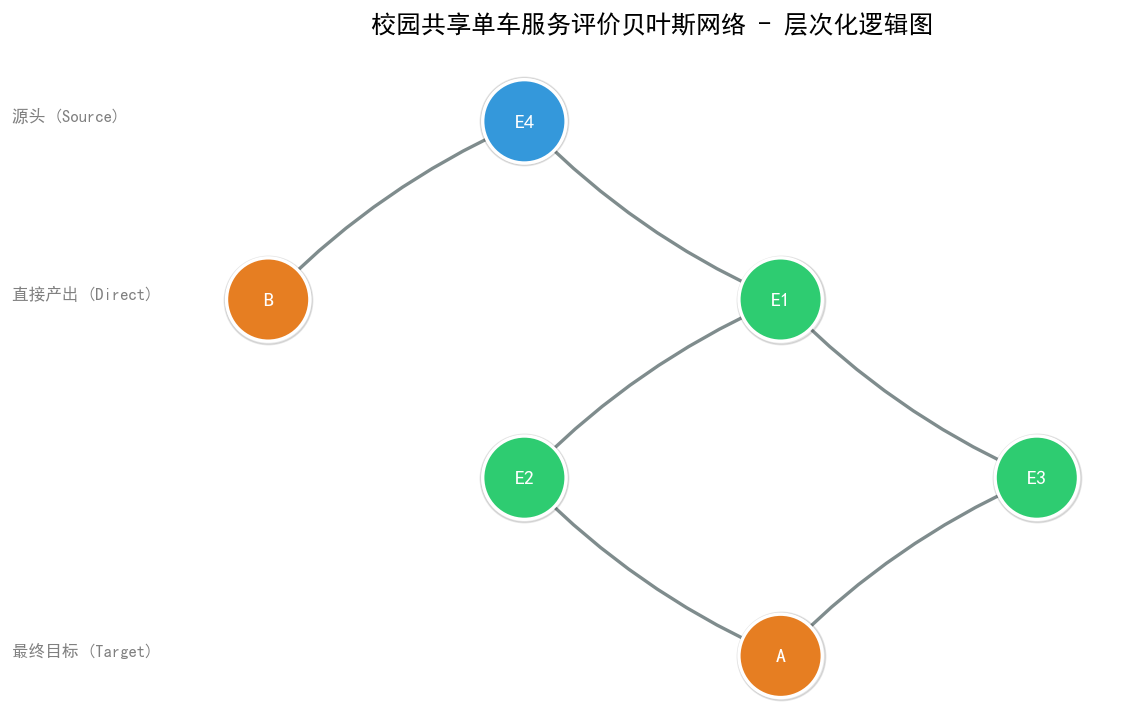

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def plot_elegant_dag(model):
    # 创建画布
    plt.figure(figsize=(10, 7), dpi=120)
    
    # 建立图对象
    G = nx.DiGraph(model.edges())
    pos = {
        'E4': (0.5, 3),   # 顶层：系统稳定性
        'B':  (0.0, 2),   # 中层左：可用率
        'E1': (1.0, 2),   # 中层右：调度能力
        'E2': (0.5, 1),   # 底层上：故障处理
        'E3': (1.5, 1),   # 底层上：抗干扰性
        'A':  (1.0, 0)    # 最底层：分布合理性
    }

    node_colors = {
        'E4': '#3498db', 
        'B':  '#e67e22', 'A': '#e67e22',  # 结果指标用橙色
        'E1': '#2ecc71', 'E2': '#2ecc71', 'E3': '#2ecc71' # 中间指标用绿色
    }
    colors = [node_colors.get(node, '#bdc3c7') for node in G.nodes()]

   
    nx.draw_networkx_nodes(G, pos, node_size=2800, node_color='black', alpha=0.1)
    
    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color=colors, 
                           edgecolors='white', linewidths=2)

    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), 
                           width=2, edge_color='#7f8c8d', 
                           arrowsize=25, arrowstyle='-|>',
                           connectionstyle="arc3,rad=0.1")

    nx.draw_networkx_labels(G, pos, font_size=12, font_color='white', 
                           font_family='sans-serif', font_weight='bold')

    plt.text(-0.5, 3, "源头 (Source)", fontsize=10, color='gray', style='italic')
    plt.text(-0.5, 2, "直接产出 (Direct)", fontsize=10, color='gray', style='italic')
    plt.text(-0.5, 0, "最终目标 (Target)", fontsize=10, color='gray', style='italic')

    plt.title("校园共享单车服务评价贝叶斯网络 - 层次化逻辑图", fontsize=15, pad=20)
    plt.axis('off')
    
    # 保存图片
    plt.savefig('beautified_dag.png', bbox_inches='tight', transparent=True)
    plt.show()

# 调用函数
plot_elegant_dag(model)

# 当前运营策略中的认知偏差与措施短板
1. **干预故障处理效率对高峰期可用率提升有限**  
代码显示干预故障处理效率对高峰期可用率的提升幅度仅为 0.0058。认知偏差：运营方可能认为“只要车修得快，高峰期就有车骑”，但数据证明，故障维修与高峰期可用性的几乎没有因果关系。短板：过分投入人力在后端维修上，并不能解决前端缺车的矛盾。高峰期的可用性由源头服务稳定性/初始投放决定，而非后期的故障追赶。
2. **忽视了故障处理对分布合理性的“一票否决权”现象**  
当 E2=0（效率低）时，无论 E3（抗干扰性）表现如何，车辆分布合理（A=1）的概率都极低（<18%）；而当 E2=1 时，A=1 的概率瞬间飙升至 85% 以上。认知偏差：管理层可能将“分布不均”归咎于天气或突发事件（E3），但在模型中，E2（故障处理及背后的调度响应）才是决定分布合理性的核心变量。短板：目前可能缺乏一套高效的“故障-调度”联动机制。如果坏车堆积无法及时处理，即便其他环节再完美，分布合理性也会彻底崩溃。
3. **“稳定性”与“合理性”的脱节现象**  
即便在 E4（服务稳定性）为“高”的情况下，分布合理性A为“高”的概率也仅有 0.4543。这说明目前的“服务稳定性”可能仅定义在“系统不宕机、App能打开”等技术层面，而没有将空间分布的动态平衡纳入稳定性指标。

# 可落地的管理优化方向
1. **建立“维修-调度”一体化响应网格**  
具体措施：将负责维修E2的人员直接转化为“流动维护员”。逻辑：既然E2是影响A的关键因子，就不能让维修员只待在仓库里，而应让他们在处理车辆故障的同时，同步承担小规模的“顺手调度”任务。以“故障点”为“分布修正点”，利用 4.2 中 E2对A的高敏感度，通过提升处理效率来直接拉动分布合理性。
2. **实施“抗干扰期”的强制人工干预预案**  
具体措施：针对 4.5 的诊断推理结果，当系统由于E2达到瓶颈而导致A降低时，不能指望系统自愈（E3此时的影响力甚至为负）。逻辑：在恶劣天气或特殊活动期间，应暂时放弃全自动化算法，改用“定点压舱”策略。在学生反映最强烈、分布最不合理的关键节点（如早八点的教学楼、晚十点的图书馆）派驻专人固守，通过强行提高局部E2来切断“故障/积压”带来的负面连锁反应。
3. **重新定义E4：从“技术稳定”转向“分布稳定”**  
具体措施：将“热点区域车辆缺口率”纳入校园服务稳定性指标。逻辑：基于 4.3 的预测，目前的稳定性无法保证合理性。通过将A的指标权重引入E4的考核中，强制运营系统在进行运力评估时，不仅考虑总量（B），更要考虑熵值（A），从源头上提高分布合理性的保底概率。

**总结：** 靠“快修车”解决不了“高峰期没车骑”的问题；要把宝贵的资源从纯维修转到“边维修边调度”上，那才是解决分布合理性的唯一方法。